In [6]:
import pandas as pd

# Make plots for three bars
import matplotlib.pyplot as plt
import os
from pathlib import Path
import src.amr_utility.name_utility as name_utility

### Create results for the best results across methods

In [2]:
# Open the results file
out_path = "./chandar_best_results.csv"
df = pd.read_csv("results_xgb_lgr_combined_20250923.csv")

df.drop(columns=['difficulty', 'clustering'], inplace=True)

# average all rows with the same: model_name,pathogen,pathogen_short,antibiotic,k,feat_mode,max_features,seed,split_method,clustering
group_cols = ['model_name','pathogen','pathogen_short','antibiotic','k','feat_mode','max_features','seed','split_method']
df_avg = df.groupby(group_cols, as_index=False).mean()
df_avg.drop(columns=["fold"], inplace=True)
df_avg.columns = [col if col in group_cols else f"mean_{col}" for col in df_avg.columns]
# Add column to each row with standard deviation of f1_macro for each group
df_std = df.groupby(group_cols, as_index=False).std()
df_std.drop(columns=["fold"], inplace=True)
df_std.columns = [col if col in group_cols else f"std_{col}" for col in df_std.columns]
df_avg = pd.merge(df_avg, df_std, on=group_cols, how='left')


# Drop all columns with clustering not equal to 'heirarchical'
df_avg = df_avg[df_avg['split_method'] == 'phylo']

# Find the model with the highest mean_f1_macro for each pathogen and antibiotic combination
best_models = df_avg.loc[df_avg.groupby(['pathogen','antibiotic'])['mean_f1_macro'].idxmax()]
print(best_models)
# Save the best models to a new CSV file
best_models.to_csv(out_path, index=False)

    model_name                 pathogen pathogen_short     antibiotic   k  \
74         XGB  acinetobacter_baumannii    a_baumannii    ceftazidime  31   
80         XGB  acinetobacter_baumannii    a_baumannii  ciprofloxacin  17   
88         XGB         escherichia_coli         e_coli       cefepime  17   
96         XGB         escherichia_coli         e_coli     cefotaxime  17   
104        XGB         escherichia_coli         e_coli       imipenem  17   
112        XGB    klebsiella_pneumoniae   k_pneumoniae      meropenem  17   
124        XGB    klebsiella_pneumoniae   k_pneumoniae     tobramycin  45   
126        XGB   pseudomonas_aeruginosa   p_aeruginosa      aztreonam   3   
136        XGB    staphylococcus_aureus       s_aureus   erythromycin  17   

    feat_mode max_features  seed split_method  mean_balanced_accuracy  \
74      count        1000K    42        phylo                0.872364   
80      count        1000K    42        phylo                0.894390   
88      co

### Instead create results for LGR and XGB separately

In [ ]:
# Open the results file
out_path = "./chandar_best_results.csv"
df = pd.read_csv("results_xgb_lgr_combined_20250923.csv")

df.drop(columns=['difficulty', 'clustering'], inplace=True)

# average all rows with the same: model_name,pathogen,pathogen_short,antibiotic,k,feat_mode,max_features,seed,split_method,clustering
group_cols = ['model_name','pathogen','pathogen_short','antibiotic','k','feat_mode','max_features','seed','split_method']
df_avg = df.groupby(group_cols, as_index=False).mean()
df_avg.drop(columns=["fold"], inplace=True)
df_avg.columns = [col if col in group_cols else f"mean_{col}" for col in df_avg.columns]
# Add column to each row with standard deviation of f1_macro for each group
df_std = df.groupby(group_cols, as_index=False).std()
df_std.drop(columns=["fold"], inplace=True)
df_std.columns = [col if col in group_cols else f"std_{col}" for col in df_std.columns]
df_avg = pd.merge(df_avg, df_std, on=group_cols, how='left')

# Drop all columns with clustering not equal to 'heirarchical'
df_avg = df_avg[df_avg['split_method'] == 'phylo']

# Only include models that have k=31
best_models = df_avg[df_avg['k'] == 31]
best_models = best_models[best_models['pathogen'] == 'escherichia_coli']
# Find the model with the highest mean_f1_macro for each pathogen and antibiotic combination
#best_models = df_avg.loc[df_avg.groupby(['model_name','pathogen','antibiotic'])['mean_f1_macro'].idxmax()]
print(best_models)
# Save the best models to a new CSV file
#best_models.to_csv(out_path, index=False)

    model_name          pathogen pathogen_short  antibiotic   k feat_mode  \
18         LGR  escherichia_coli         e_coli    cefepime  31     count   
26         LGR  escherichia_coli         e_coli  cefotaxime  31     count   
34         LGR  escherichia_coli         e_coli    imipenem  31     count   
90         XGB  escherichia_coli         e_coli    cefepime  31     count   
98         XGB  escherichia_coli         e_coli  cefotaxime  31     count   
106        XGB  escherichia_coli         e_coli    imipenem  31     count   

    max_features  seed split_method  mean_balanced_accuracy  mean_f1_macro  \
18         1000K    42        phylo                0.653397       0.669580   
26         1000K    42        phylo                0.707286       0.689187   
34         1000K    42        phylo                0.532231       0.523472   
90         1000K    42        phylo                0.670539       0.687961   
98         1000K    42        phylo                0.756683       0.73

Saved easy_cases_f1.png
Saved medium_cases_f1.png
Saved hard_cases_f1.png


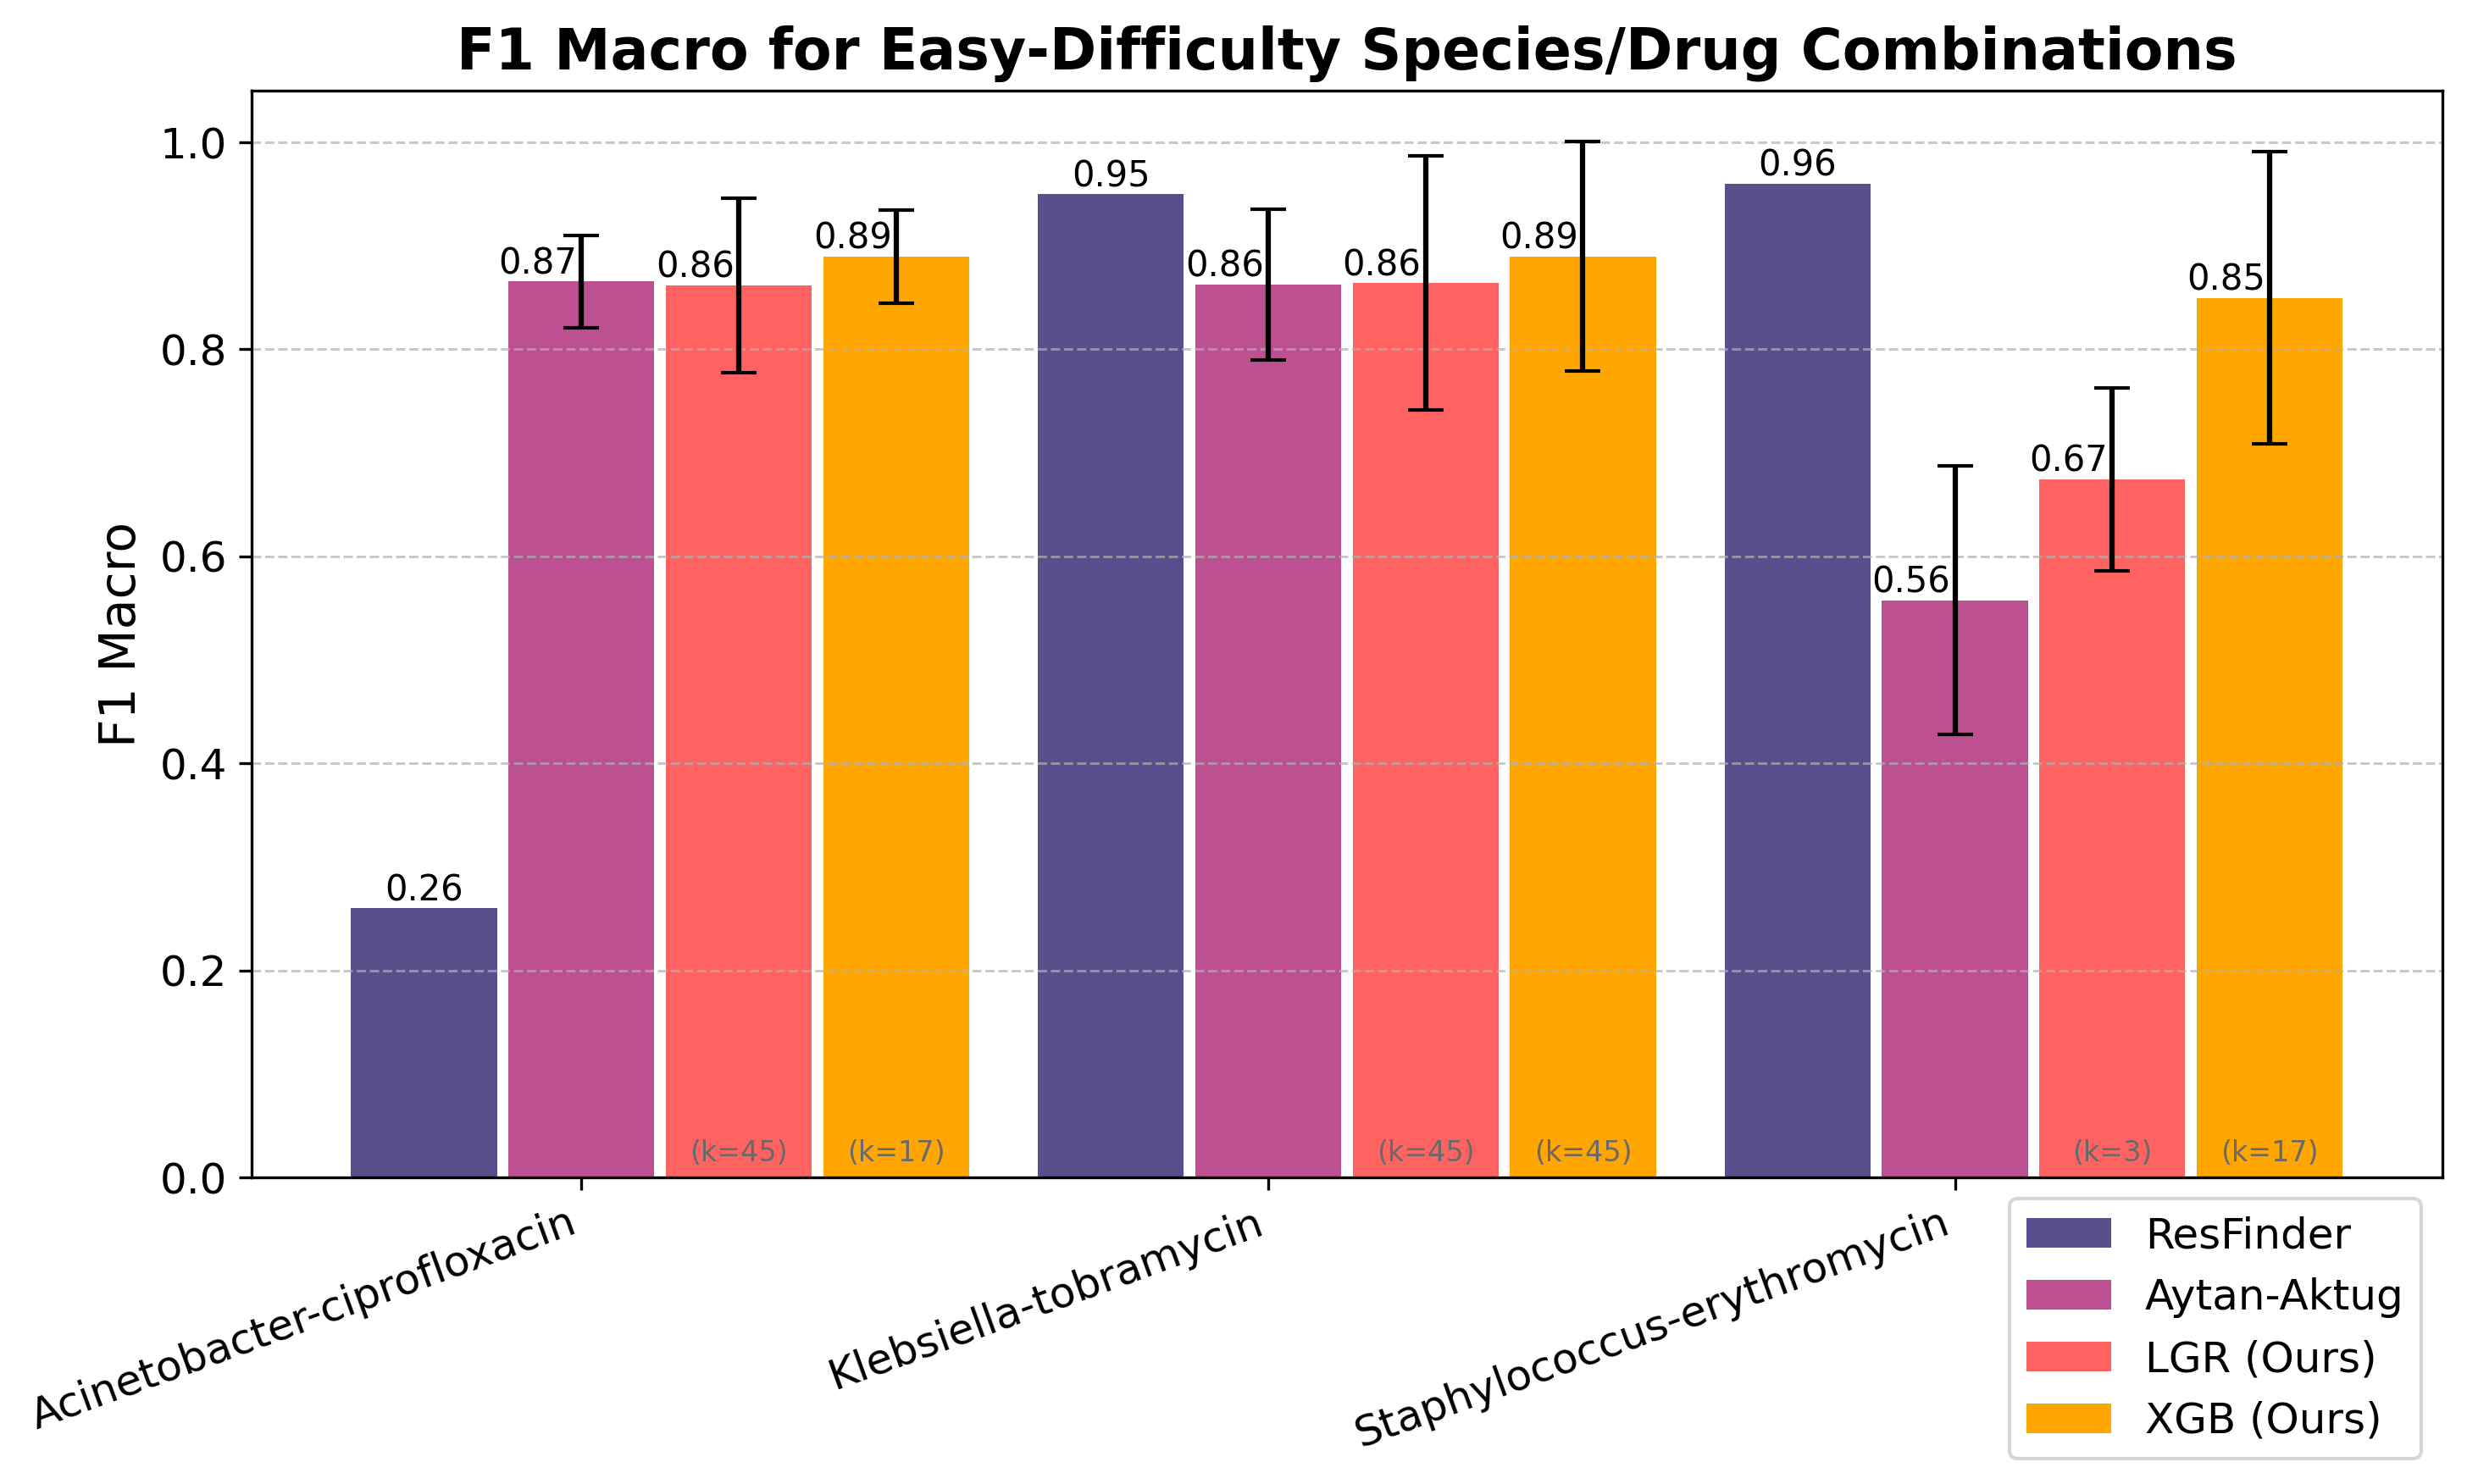

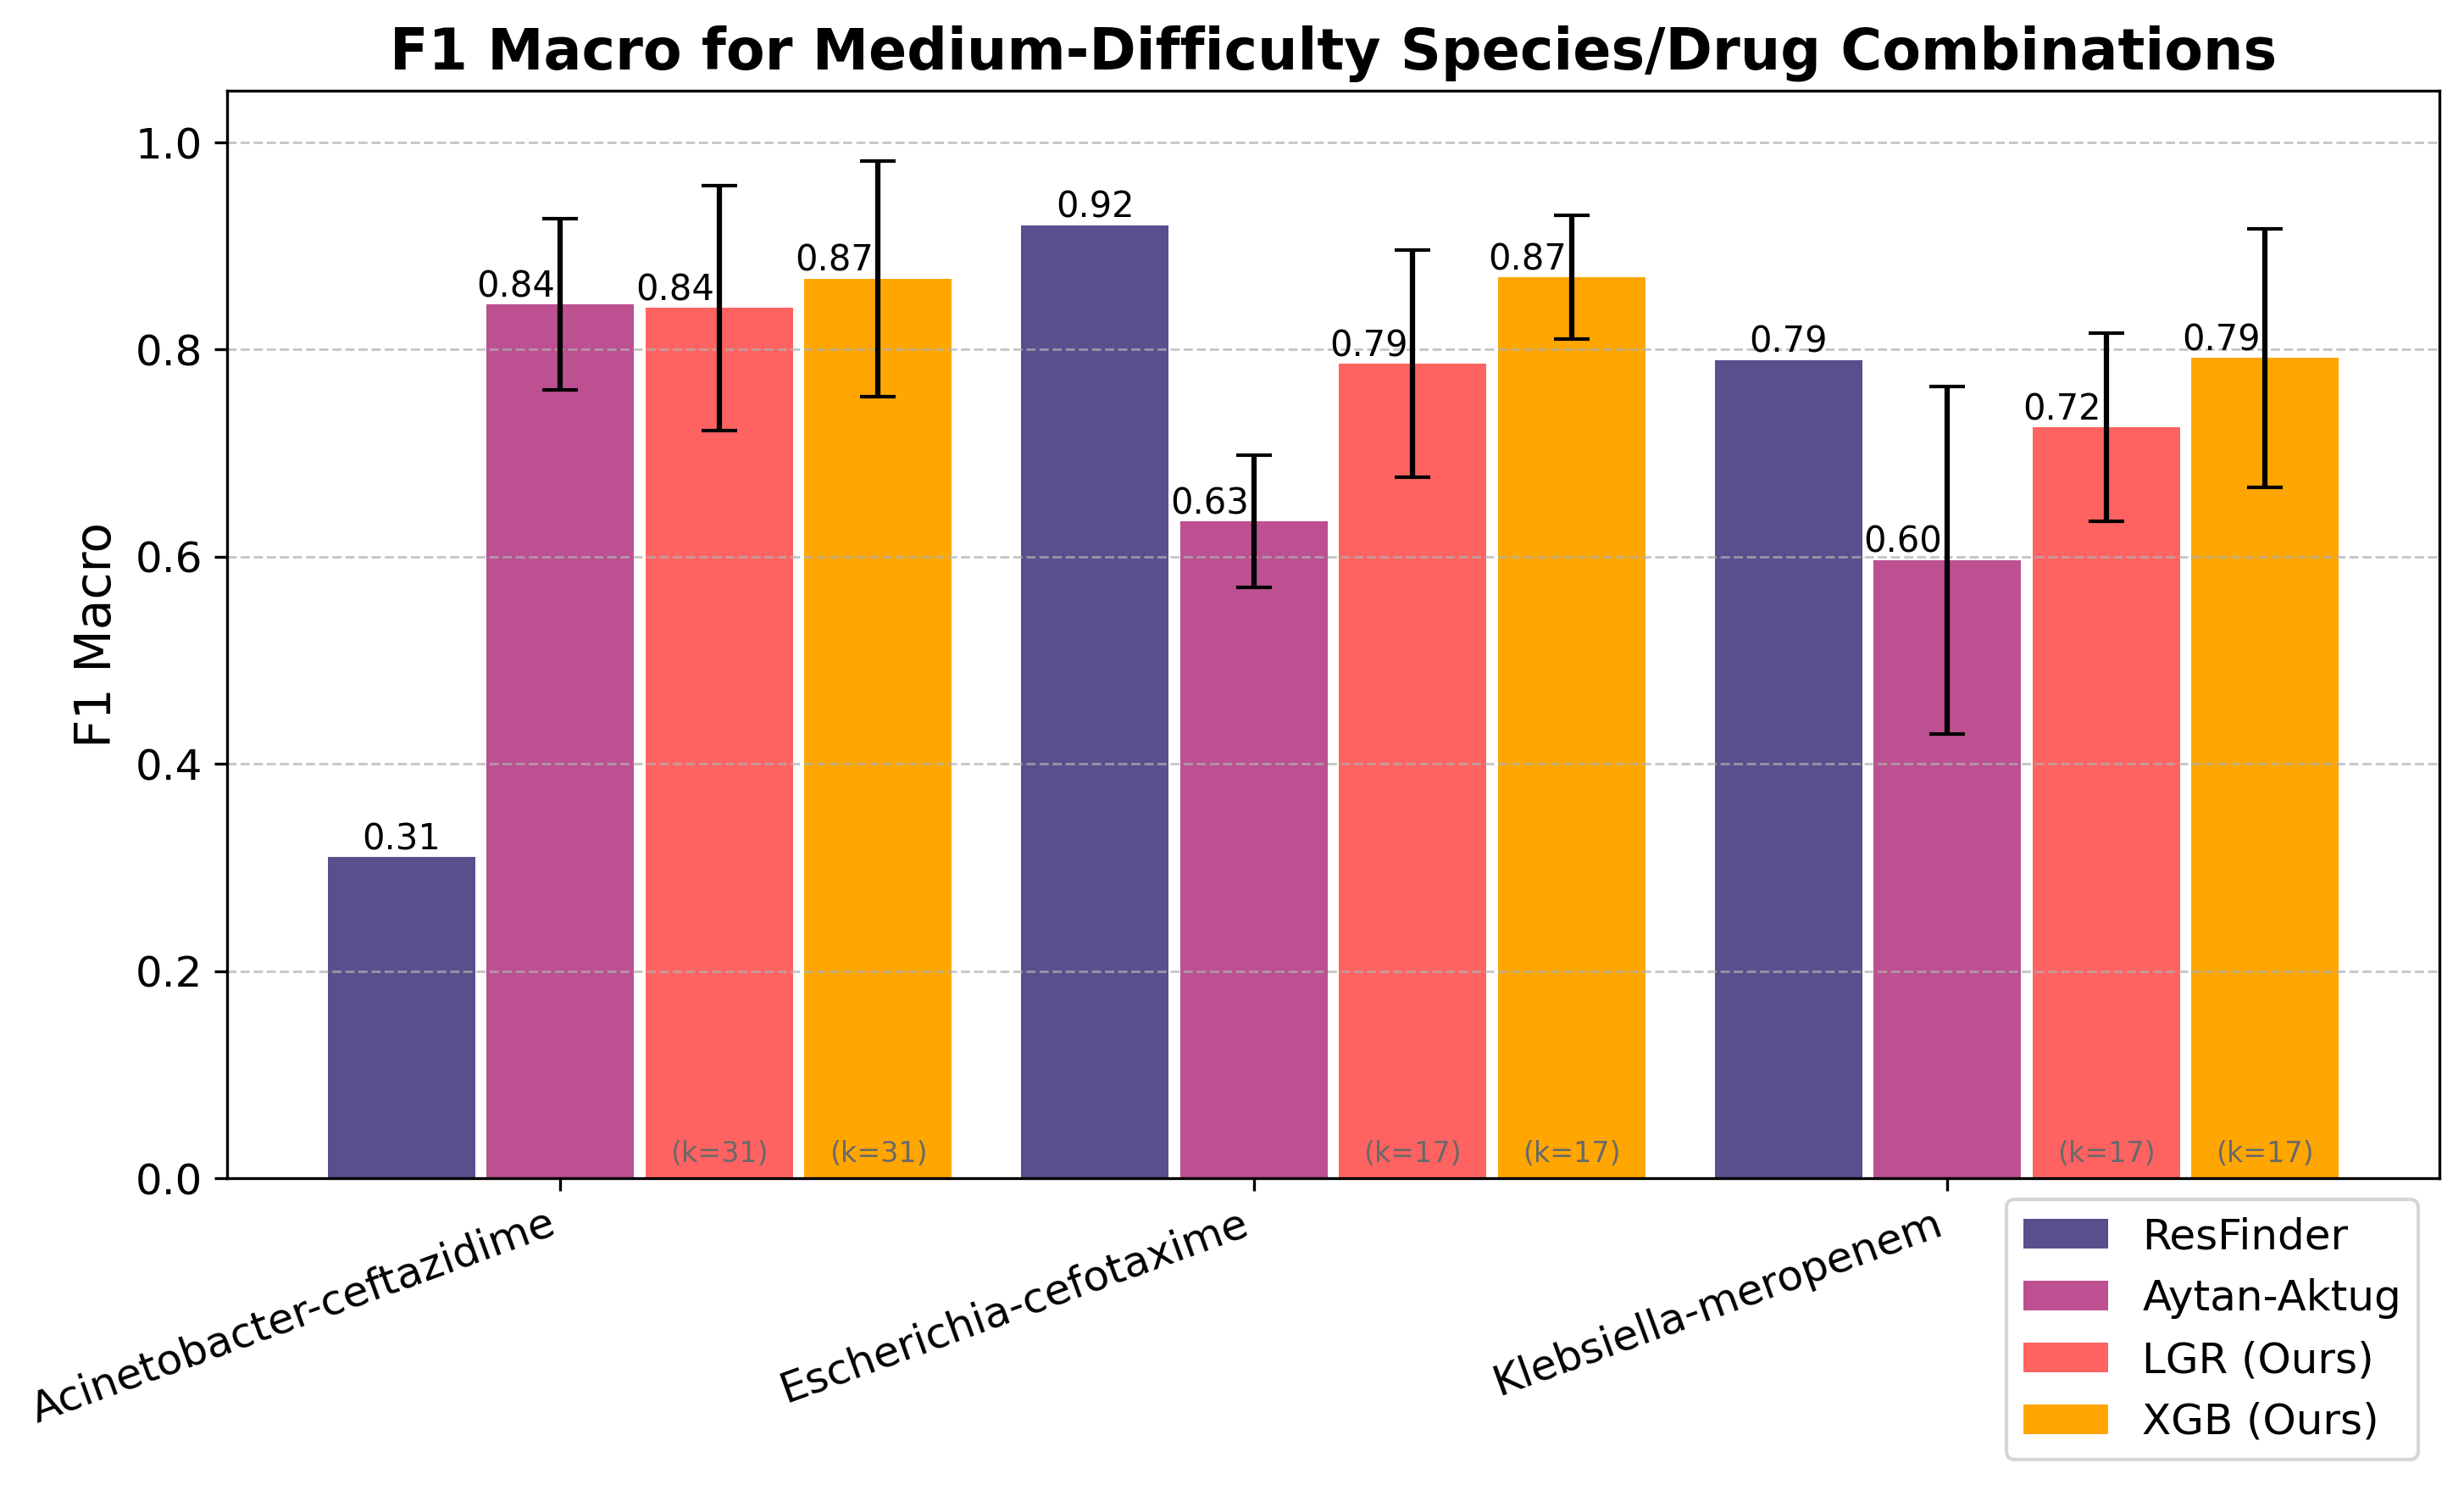

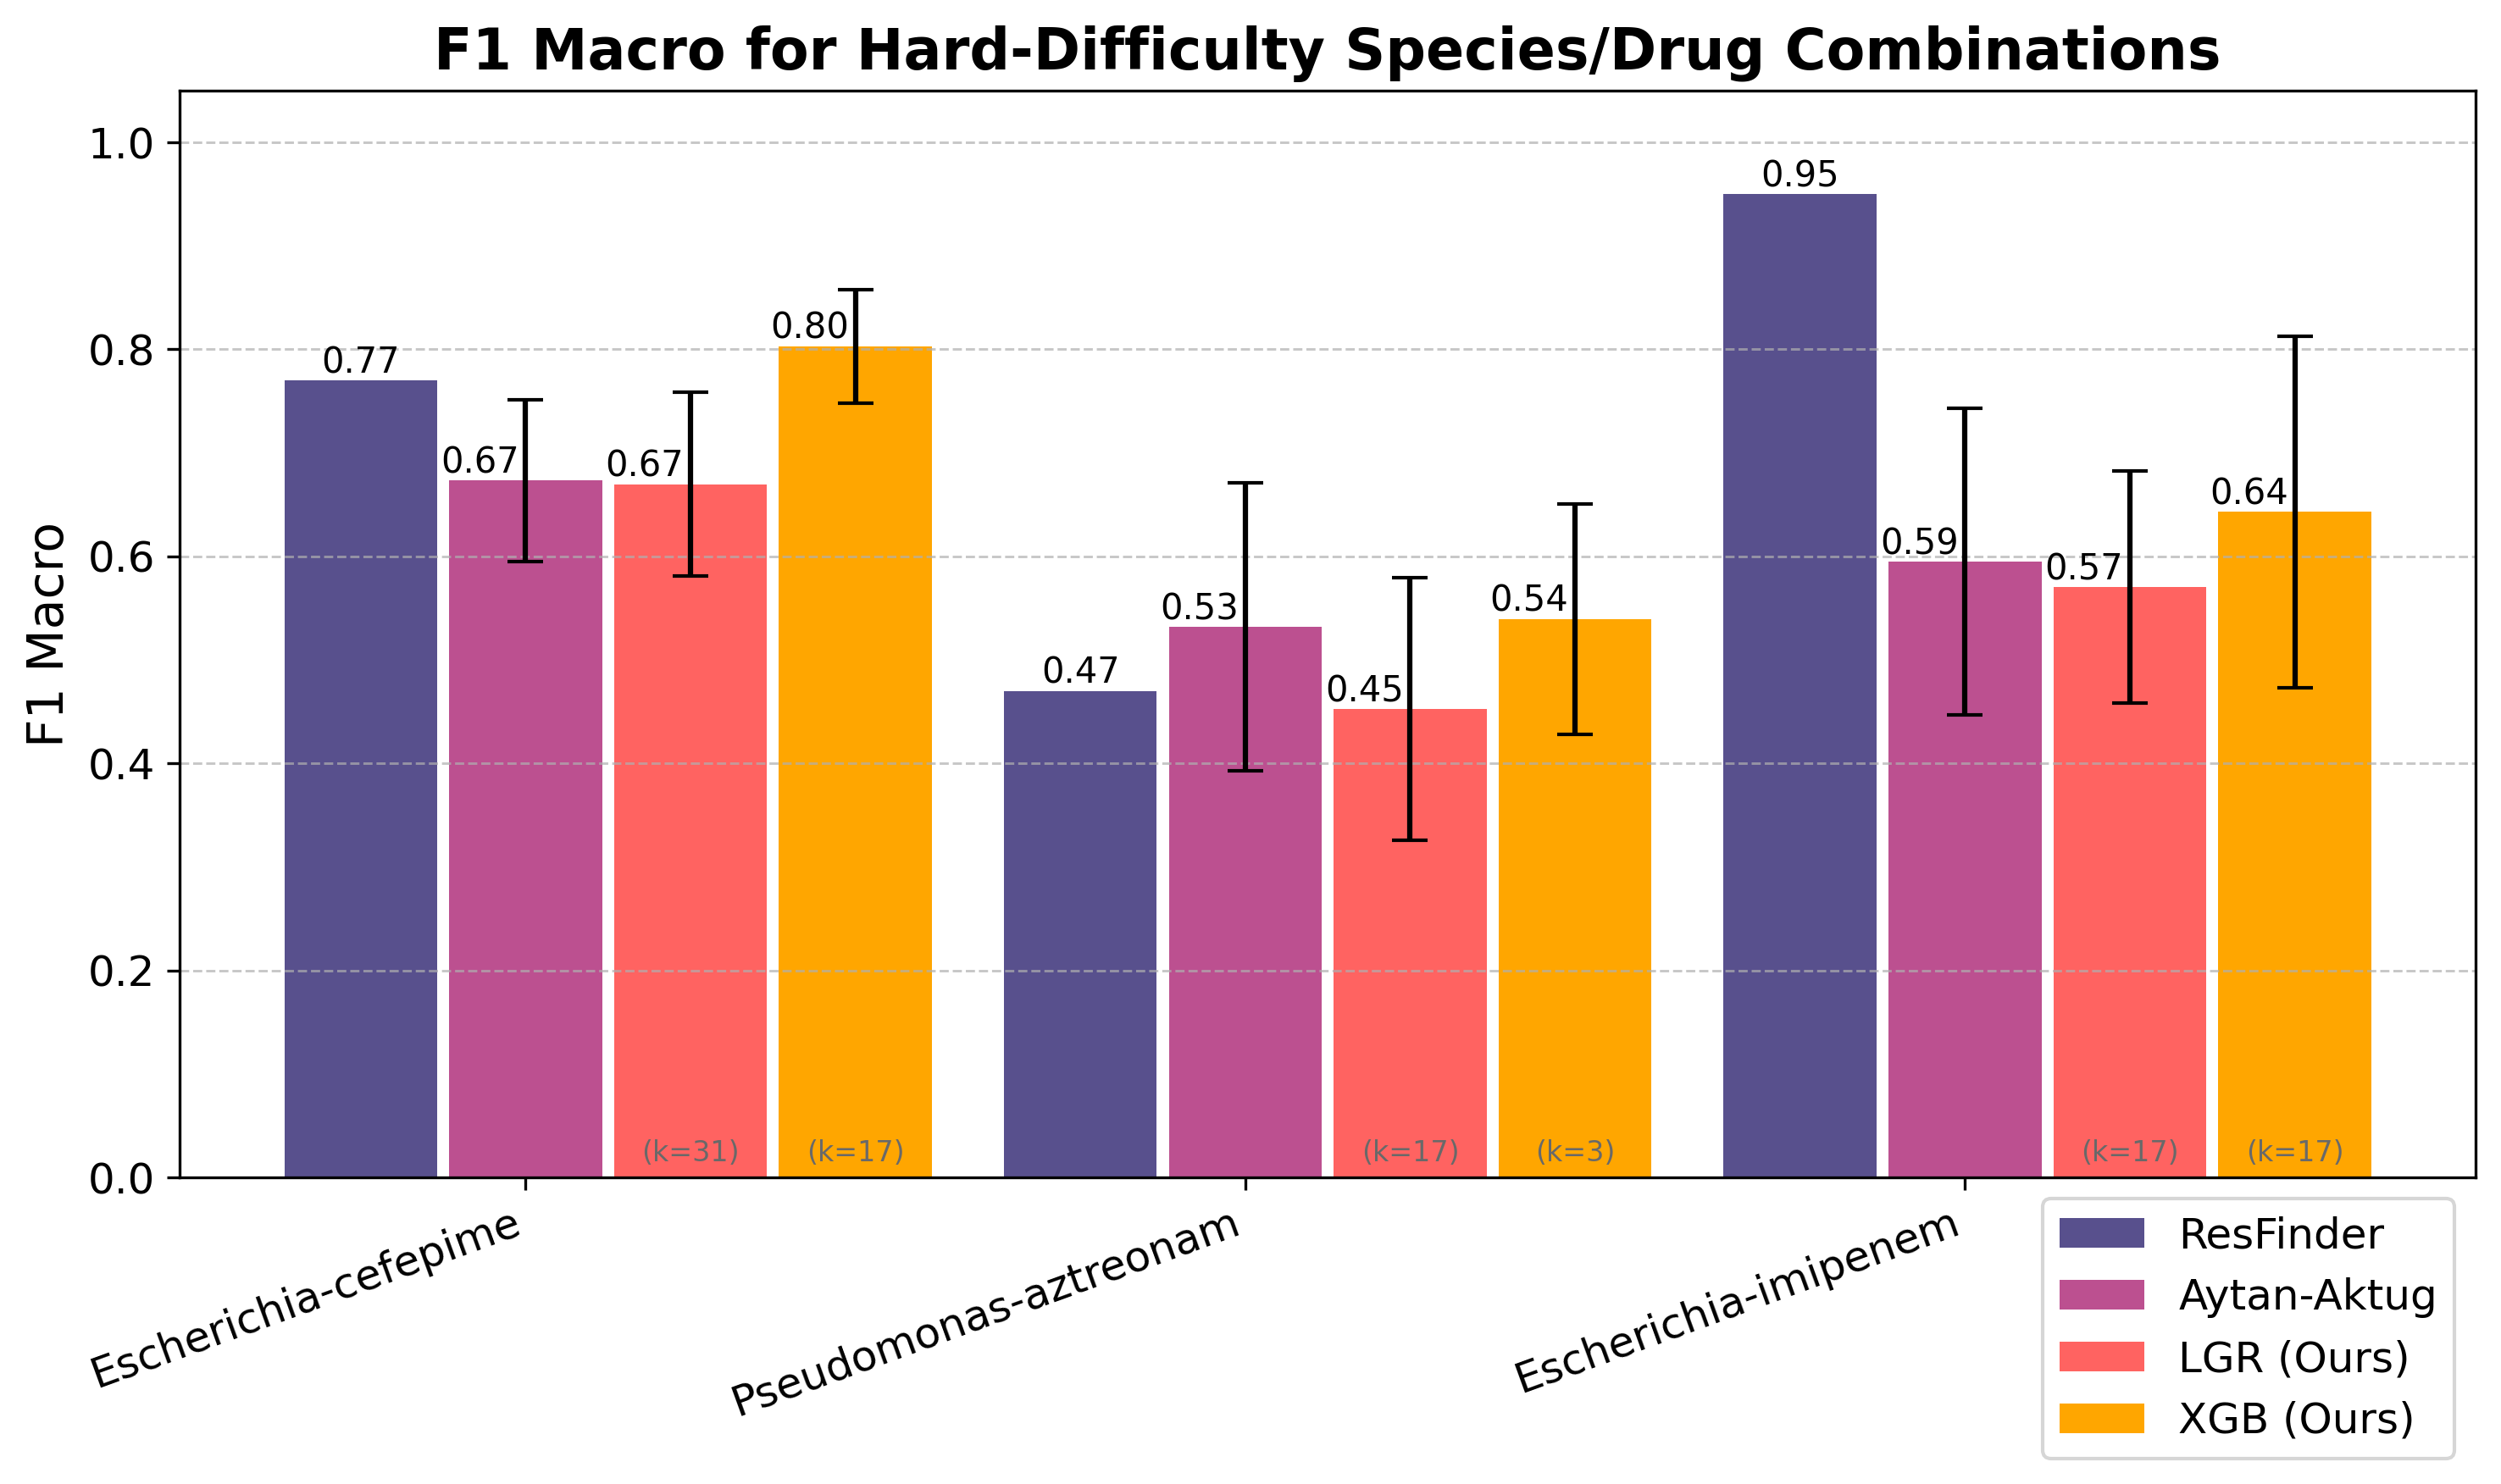

In [ ]:
# NICE PLOTS STUFF from ChatGPT
plt.rcParams.update({
    "font.size": 12,
})

species = ['Escherichia coli', 'Klebsiella pneumoniae', 'Acinetobacter baumannii',
           'Staphylococcus aureus', 'Pseudomonas aeruginosa']
species_drugs = []
all_resfinder_f1s = {}
all_aytan_f1s = {}

# Open the resfinder results for each species
all_resfinder_dataframes = []
for sp in species:
    file_path = name_utility.GETname_ResfinderResults(sp, "resfinder_b", "./") + ".csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, delimiter="\t", index_col=0)
        all_resfinder_dataframes.append(df)
        # Get the list of drugs for this species
        drugs = df.index.tolist()
        for drug in drugs:
            species_drugs.append((sp, drug))
            all_resfinder_f1s[(sp, drug)] = (df.loc[drug, 'f1_macro'])
    else:
        print(f"Warning: {file_path} does not exist and will be skipped.")

# Open the aytan-aktug results for each species
aytan_aktug_data = {}
for sp in species:
    file_format = name_utility.GETname_AAresult("AytanAktug",sp,0.0, 0,True,False,"f1_macro",False,True,"SSSA","./")
    metrics_file = Path(file_format + "_SummaryBenchmarking_PLOT.txt")
    stds_file = Path(file_format + "_SummaryBenchmarking_std.txt")
    if os.path.exists(metrics_file):
        if not os.path.exists(stds_file):
            print(f"Warning: {stds_file} does not exist. Standard deviations will not be available.")
        f1_df = pd.read_csv(metrics_file, delimiter="\t", index_col=0)
        stds_df = pd.read_csv(stds_file, delimiter="\t", index_col=0)
        # Merge the two dataframes on the index (drug names)
        df = pd.merge(f1_df, stds_df, left_index=True, right_index=True, suffixes=('', '_std'))
        # Get the list of drugs for this species
        drugs = df.index.tolist()
        for drug in drugs:
            aytan_aktug_data[(sp, drug)] = (df.loc[drug, 'f1_macro'], df.loc[drug, 'f1_macro_std'])
    else:
        print(f"Warning: {metrics_file} does not exist and will be skipped.")



chandar_df = pd.read_csv("chandar_best_results.csv")
chandar_data_lgr = {}
chandar_data_xgb = {}
for index, row in chandar_df.iterrows():
    species_name = row['pathogen'].capitalize().replace('_', ' ')
    drug_name = row['antibiotic']
    k_size = row['k']
    if (species_name, drug_name) not in all_resfinder_f1s:
        print(f"Warning: ({species_name}, {drug_name}) from Chandar data not found in ResFinder data.")
    else:
        if row['model_name'] == "LGR":
            chandar_data_lgr[(species_name, drug_name)] = (row['mean_f1_macro'], k_size, row['std_f1_macro'])
        elif row['model_name'] == "XGB":
            chandar_data_xgb[(species_name, drug_name)] = (row['mean_f1_macro'], k_size, row['std_f1_macro'])
        # Add a new column to the dataframe for ResFinder accuracy

easy = [('Acinetobacter baumannii', 'ciprofloxacin'), ('Klebsiella pneumoniae', 'tobramycin'), ('Staphylococcus aureus', 'erythromycin')]
med = [('Acinetobacter baumannii', 'ceftazidime'), ('Escherichia coli', 'cefotaxime'), ('Klebsiella pneumoniae', 'meropenem')]
hard = [('Escherichia coli', 'cefepime'), ('Pseudomonas aeruginosa', 'aztreonam'), ('Escherichia coli', 'imipenem')]

# Create bar charts for each of the easy, medium, and hard categories
# Include 2 bars per species-drug pair: one for Chandar et al. and one for ResFinder
categories = {'Easy': easy, 'Medium': med, 'Hard': hard}

for category, pairs in categories.items():
    plt.figure(figsize=(10, 6), dpi=300)  # high resolution (300 dpi)

    chandar_lgr_f1s = [chandar_data_lgr[pair][0] for pair in pairs]
    chandar_lgr_ks = [chandar_data_lgr[pair][1] for pair in pairs]
    chandar_lgr_stds = [chandar_data_lgr[pair][2] for pair in pairs]
    chandar_xgb_f1s = [chandar_data_xgb[pair][0] for pair in pairs]
    chandar_xgb_ks = [chandar_data_xgb[pair][1] for pair in pairs]
    chandar_xgb_stds = [chandar_data_xgb[pair][2] for pair in pairs]
    resfinder_f1s = [all_resfinder_f1s[pair] for pair in pairs]
    aytan_aktug_f1s = [aytan_aktug_data[pair][0] for pair in pairs]
    aytan_aktug_stds = [aytan_aktug_data[pair][1] for pair in pairs]
    labels = [f"{pair[0].split()[0]}-{pair[1]}" for pair in pairs]
    # Set x to work for 4 bars per group
    num_bars = 4
    num_pairs = len(pairs)
    x = list(range(num_pairs))

    bar_width = 1/num_bars * 0.85 # 90% of the space is allocated to bars
    bar_spacing = bar_width + 0.15/(num_bars+5) # +3 for spacing between groups

    # Bars
    plt.bar(x, resfinder_f1s, width=bar_width, label='ResFinder',
            color='#58508d', align='center')
    plt.bar([p + bar_spacing for p in x], aytan_aktug_f1s, width=bar_width, label='Aytan-Aktug',
            color='#bc5090', align='center')
    plt.bar([p + 2*bar_spacing for p in x], chandar_lgr_f1s, width=bar_width, label='LGR (Ours)',
            color='#ff6361', align='center')
    plt.bar([p + 3*bar_spacing for p in x], chandar_xgb_f1s, width=bar_width, label='XGB (Ours)',
            color='#ffa600', align='center')
    

    # Limits & labels
    plt.ylim(0, 1.05)
    plt.ylabel('F1 Macro', fontsize=14)
    plt.title(f'F1 Macro for {category}-Difficulty Species/Drug Combinations', fontsize=16, fontweight='bold')

    # X ticks
    plt.xticks([p + bar_spacing for p in x], labels, rotation=20, ha='right')

    # Add error bars for Chandar/Aktug models
    plt.errorbar([p + bar_spacing for p in x], aytan_aktug_f1s, yerr=aytan_aktug_stds, fmt='none', ecolor='black', capsize=5)
    plt.errorbar([p + 2*bar_spacing for p in x], chandar_lgr_f1s, yerr=chandar_lgr_stds, fmt='none', ecolor='black', capsize=5)
    plt.errorbar([p + 3*bar_spacing for p in x], chandar_xgb_f1s, yerr=chandar_xgb_stds, fmt='none', ecolor='black', capsize=5)
    
    # Value labels above bars
    for i, v in enumerate(resfinder_f1s):
        plt.text(i, v, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
    for i, v in enumerate(aytan_aktug_f1s):
        vert_pos = v
        plt.text(i-0.3*bar_width + bar_spacing, vert_pos, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
    for i, v in enumerate(chandar_lgr_f1s):
        vert_pos = v
        plt.text(i-0.3*bar_width + 2*bar_spacing, vert_pos, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
        plt.text(i + 2*bar_spacing, 0.01, f"(k={chandar_lgr_ks[i]})", ha='center', va='bottom', fontsize=8, color='dimgrey')
    for i, v in enumerate(chandar_xgb_f1s):
        vert_pos = v
        plt.text(i -0.3*bar_width+ 3*bar_spacing, vert_pos, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
        plt.text(i + 3*bar_spacing, 0.01, f"(k={chandar_xgb_ks[i]})", ha='center', va='bottom', fontsize=8, color='dimgrey')

    # Legend
    plt.legend(frameon=True, fontsize=12, bbox_to_anchor=(1, 0))

    # Prettier grid (dashed, light gray)
    plt.grid(axis='y', linestyle='--', linewidth=0.7, alpha=0.7)

    # Tight layout to avoid cutoff
    plt.tight_layout()

    # Save high-quality PNG
    plt.savefig(f"{category.lower()}_cases_f1.png", dpi=300, bbox_inches="tight")
    print("Saved", f"{category.lower()}_cases_f1.png")

Saved escherichia_coli_cefepime_f1_comparison.png


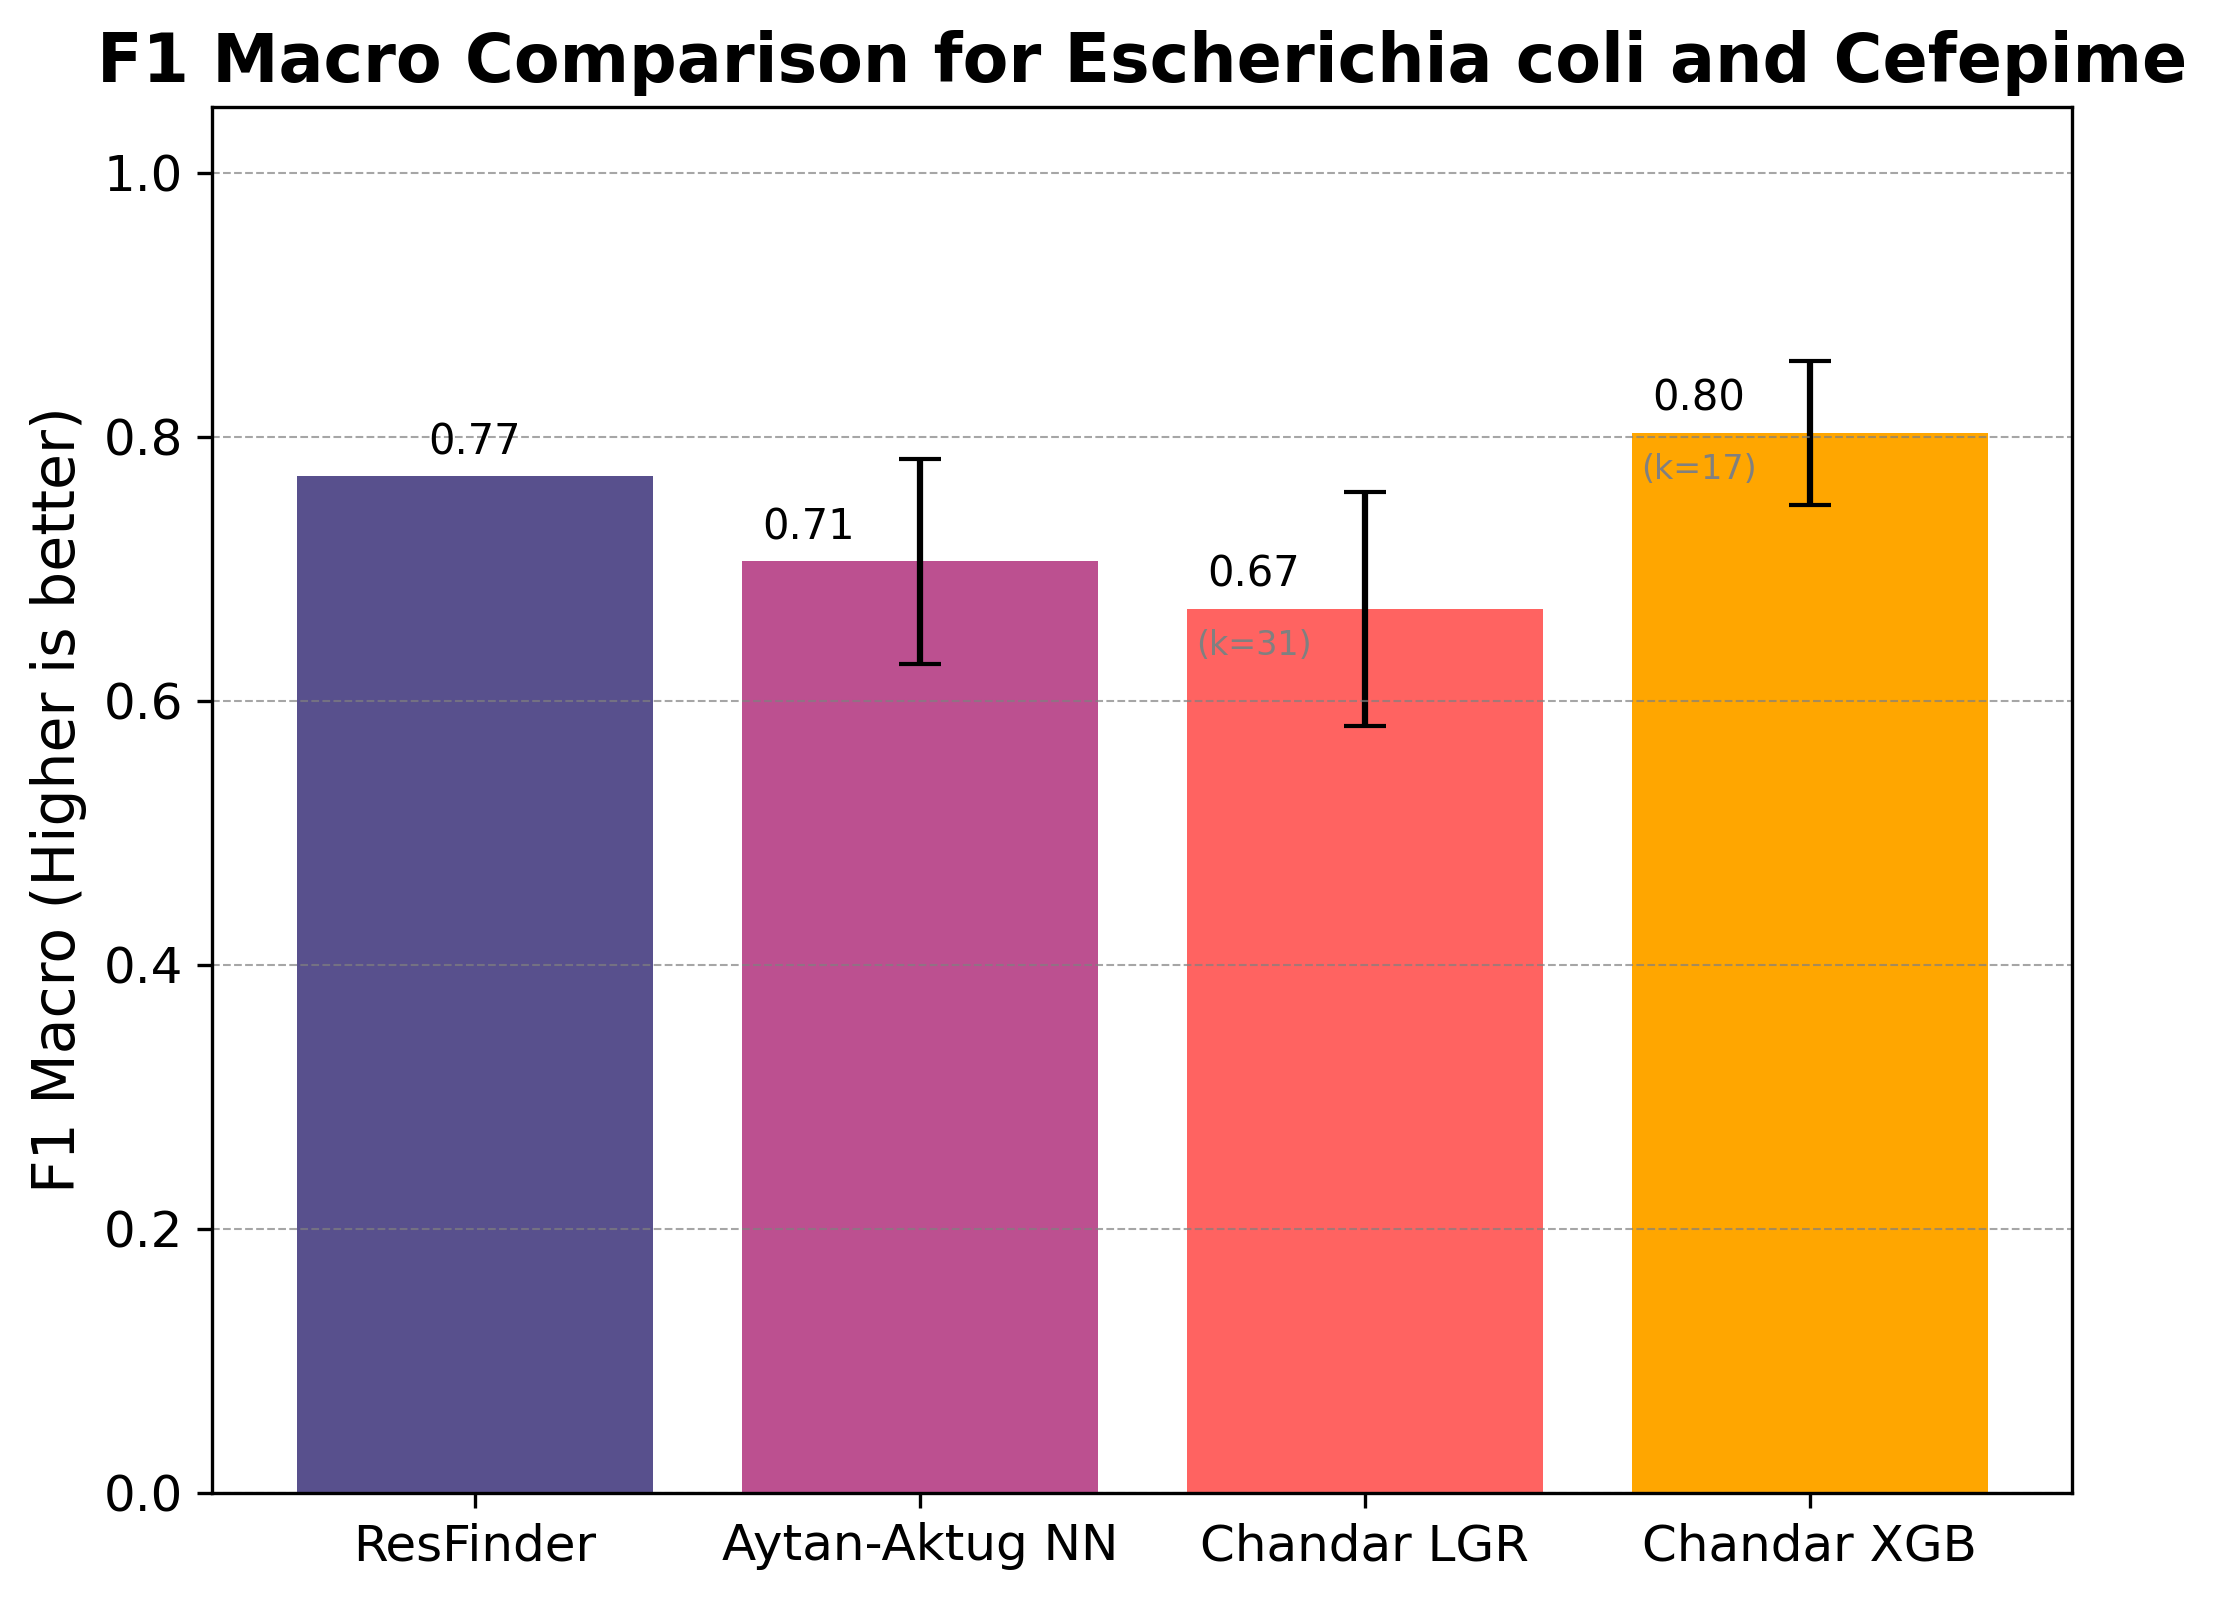

In [ ]:
# Load the results for aytan aktug
ayten_aktug_results = name_utility.GETname_AAresult("AytanAktug","Escherichia coli",0.0, 0,True,False,"f1_macro",False,True,"SSSA","./") + "_SummaryBenchmarking_PLOT.txt"
ayten_df = pd.read_csv(ayten_aktug_results, delimiter="\t", index_col=0)
# Load the STDS
aytan_stds = pd.read_csv(ayten_aktug_results.replace("PLOT.txt", "std.txt"), delimiter="\t", index_col=0)
# extract the std for weighted-f1_macro
ayten_std = aytan_stds.loc['cefepime', 'weighted-f1_macro']
# extract resfinder and chandar f1_macro values for (Escherichia coli, cefepime)
resfinder_f1 = all_resfinder_f1s[('Escherichia coli', 'cefepime')]
lgr_f1 = chandar_data_lgr[('Escherichia coli', 'cefepime')][0]
xgb_f1 = chandar_data_xgb[('Escherichia coli', 'cefepime')][0]
lgr_std = chandar_data_lgr[('Escherichia coli', 'cefepime')][2]
xgb_std = chandar_data_xgb[('Escherichia coli', 'cefepime')][2]
# extract ayten weighted-f1_macro
ayten_f1 = ayten_df.loc['cefepime', 'weighted-f1_macro']
# Create a bar chart comparing the four methods
plt.figure(figsize=(8, 6), dpi=300)  # high resolution (300 dpi)
methods = ['ResFinder', 'Aytan-Aktug NN', 'Chandar LGR', 'Chandar XGB']
f1_scores = [resfinder_f1, ayten_f1, lgr_f1, xgb_f1]
plt.bar(methods, f1_scores, color=['#58508d', '#bc5090', '#ff6361', '#ffa600'])
plt.ylim(0, 1.05)
plt.ylabel('F1 Macro (Higher is better)', fontsize=14)
plt.title('F1 Macro Comparison for Escherichia coli and Cefepime', fontsize=16, fontweight='bold')
# Add error bars for Chandar models and aytan
plt.errorbar(2, lgr_f1, yerr=lgr_std, fmt='none', ecolor='black', capsize=5)
plt.errorbar(3, xgb_f1, yerr=xgb_std, fmt='none', ecolor='black', capsize=5)
plt.errorbar(1, ayten_f1, yerr=ayten_std, fmt='none', ecolor='black', capsize=5)

# Add dashed lines every 0.2 from 0 to 1.0
for y in range(0, 11, 2):  # 0, 2, 4, 6, 8, 10
    y = y / 10.0
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Value labels above bars
for i, v in enumerate(f1_scores):
    if i >= 1:
        plt.text(i-0.25, v +0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
        # add k value below the f1 score
        if i >= 2:
            k_value = chandar_data_lgr[('Escherichia coli', 'cefepime')][1] if i == 2 else chandar_data_xgb[('Escherichia coli', 'cefepime')][1]
            plt.text(i-0.25, v - 0.04, f"(k={k_value})", ha='center', va='bottom', fontsize=8, color='gray')
    else:
        plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
# Save high-quality PNG
plt.savefig("escherichia_coli_cefepime_f1_comparison.png", dpi=300, bbox_inches="tight")
print("Saved", "escherichia_coli_cefepime_f1_comparison.png")


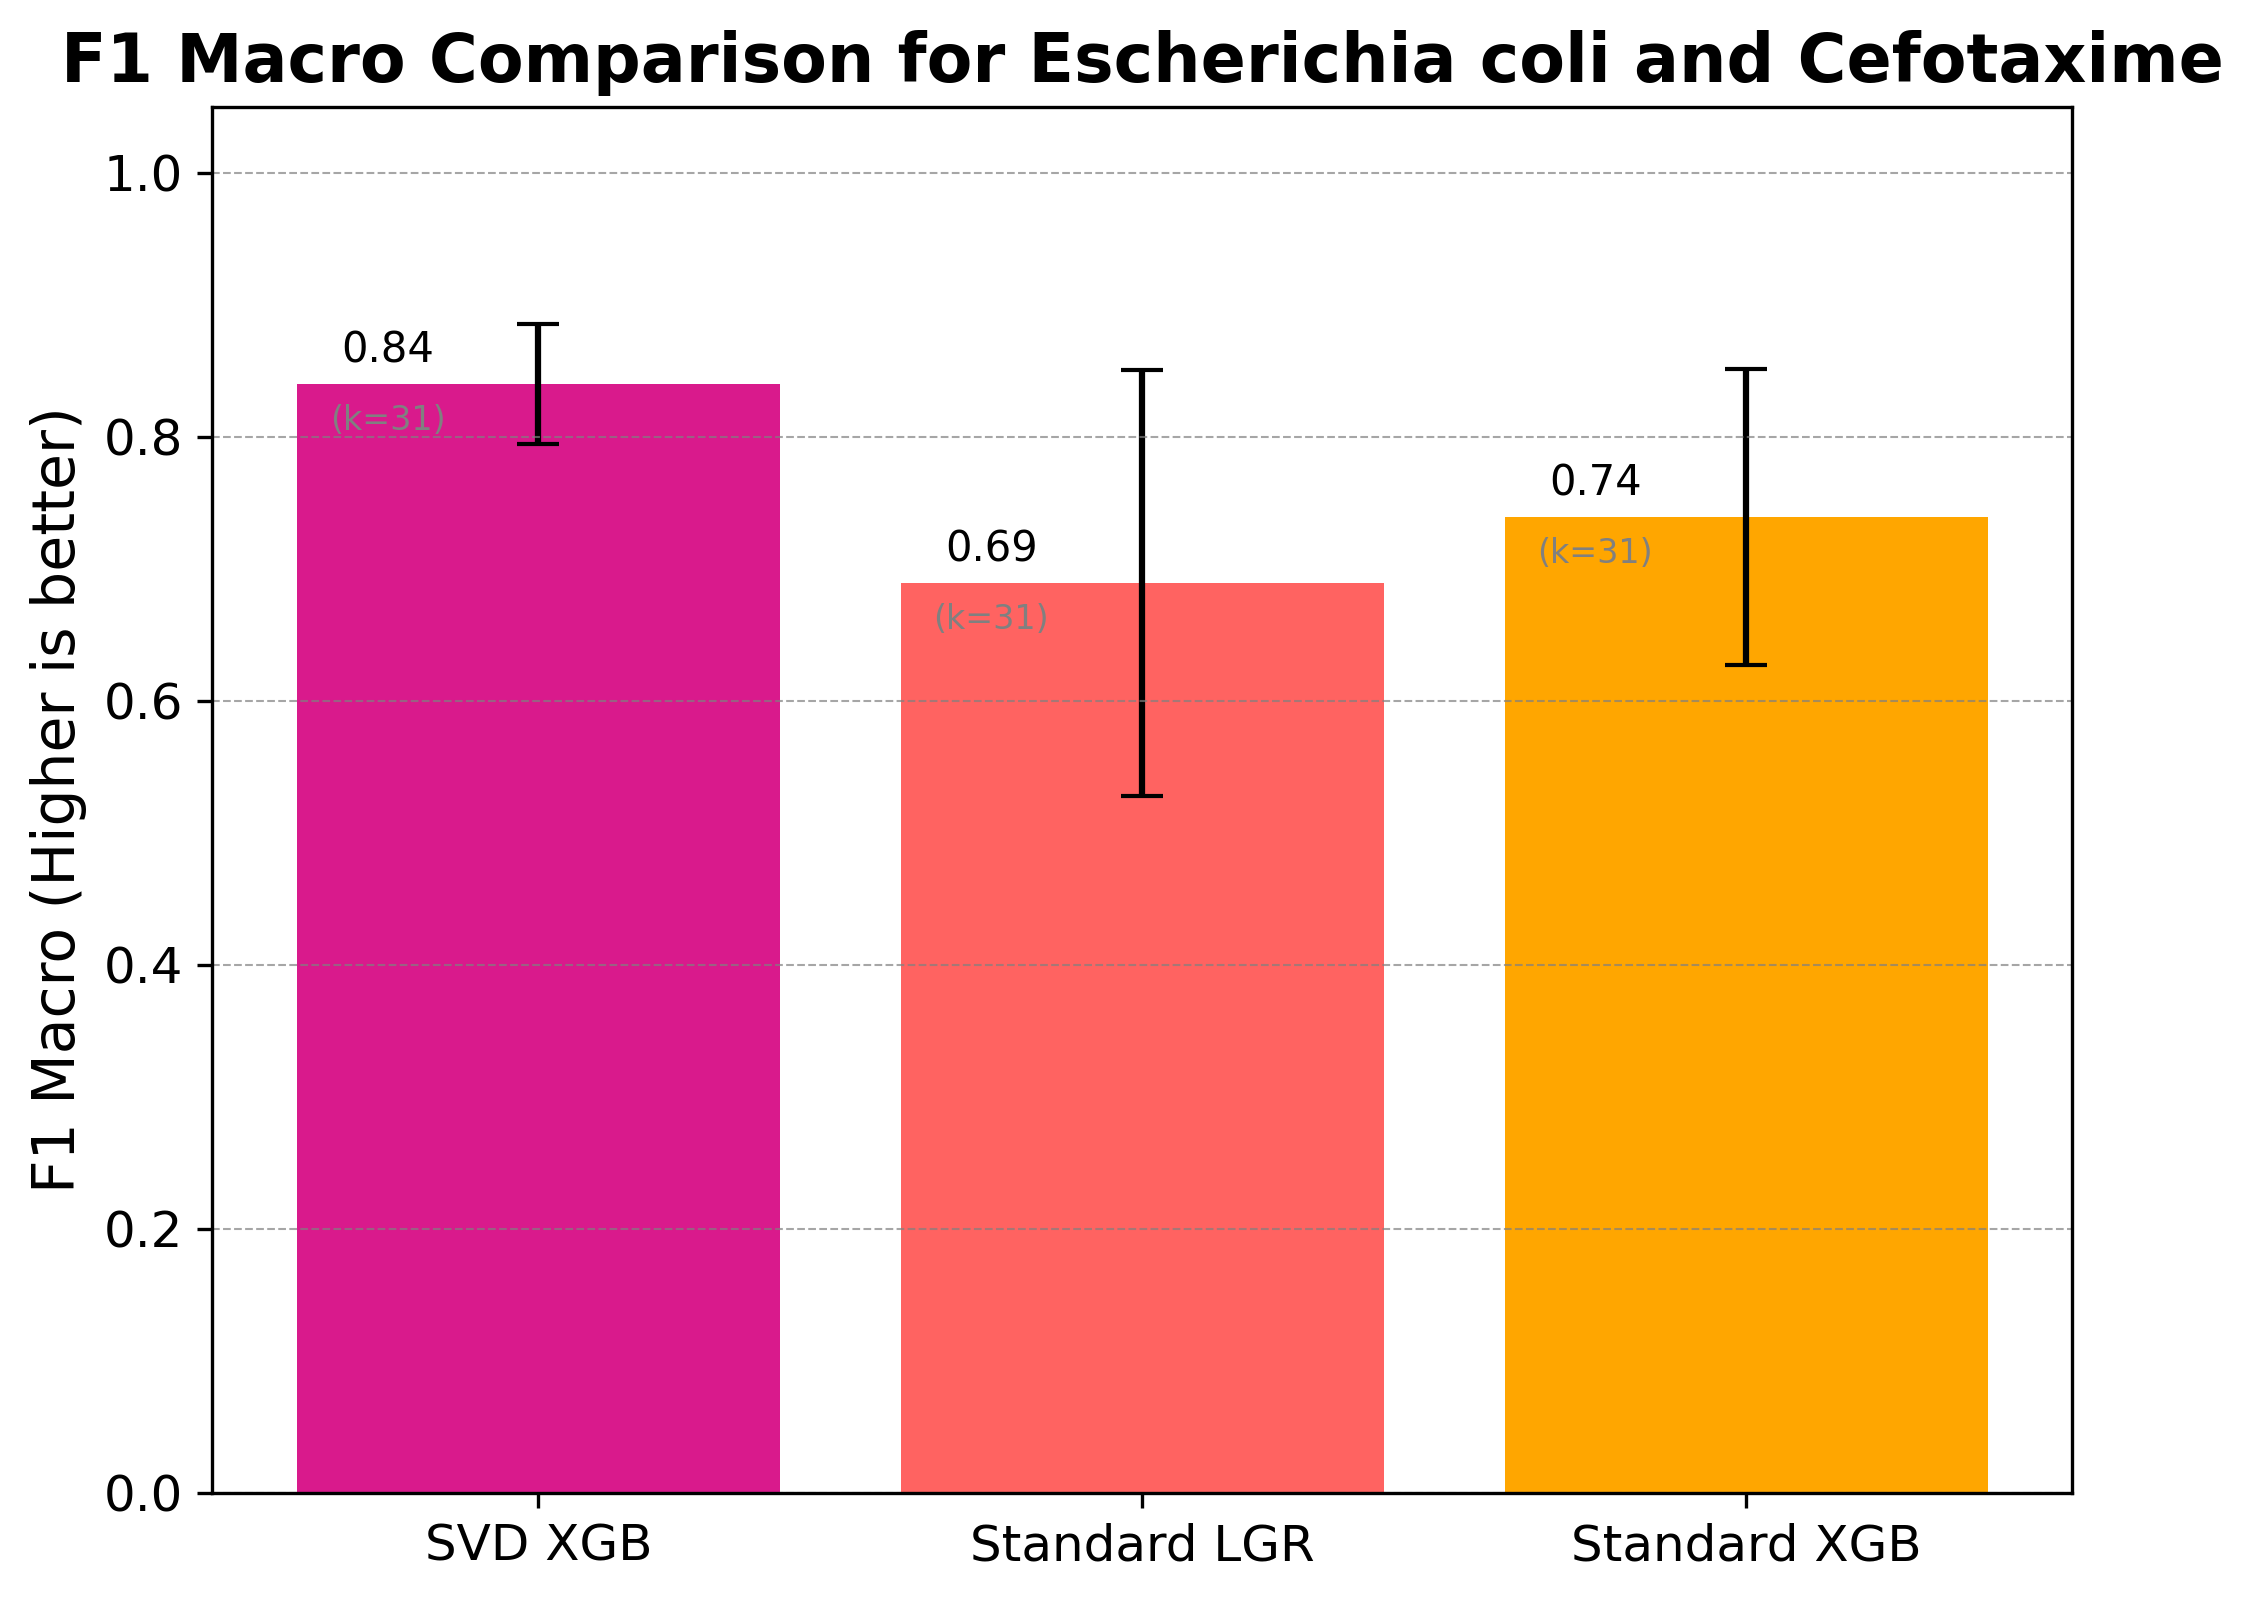

In [ ]:
# NICE PLOTS STUFF from ChatGPT
plt.rcParams.update({
    "font.size": 12,
})

# Data
methods = ["SVD XGB", "Standard LGR", "Standard XGB"]
f1_scores = [0.8399, 0.689187, 0.739149]
std_devs = [0.0456, 0.161129, 0.112200]

# X positions
x_pos = np.arange(len(methods))

# Create a bar chart comparing the four methods
plt.figure(figsize=(8, 6), dpi=300)  # high resolution (300 dpi)
plt.bar(methods, f1_scores, color=["#d91a8c", '#ff6361', '#ffa600'])
plt.ylim(0, 1.05)
plt.ylabel('F1 Macro (Higher is better)', fontsize=14)
plt.title('F1 Macro Comparison for Escherichia coli and Cefotaxime', fontsize=16, fontweight='bold')
# Add error bars
for i in range(len(methods)):
    plt.errorbar(i, f1_scores[i], yerr=std_devs[i], fmt='none', ecolor='black', capsize=5)

# Add dashed lines every 0.2 from 0 to 1.0
for y in range(0, 11, 2):  # 0, 2, 4, 6, 8, 10
    y = y / 10.0
    plt.axhline(y=y, color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

# Value labels above bars
for i, v in enumerate(f1_scores):
    plt.text(i-0.25, v +0.01, f"{v:.2f}", ha='center', va='bottom', fontsize=10)
    # add k value below the f1 score
    plt.text(i-0.25, v - 0.04, f"(k=31)", ha='center', va='bottom', fontsize=8, color='gray')

# Save high-quality PNG
plt.show()
# plt.savefig("escherichia_coli_cefepime_f1_comparison.png", dpi=300, bbox_inches="tight")
# print("Saved", "escherichia_coli_cefepime_f1_comparison.png")

